<a href="https://colab.research.google.com/github/will-mccormack/CS-M148-Proj/blob/main/COM_SCI_M148_NN_with_genre_with_PCA_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, utils
from sklearn.preprocessing import StandardScaler
import time
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from matplotlib import lines

In [ ]:
train_filepath = "https://raw.githubusercontent.com/will-mccormack/CS-M148-Proj/main/Data/train.csv"
validation_filepath = "https://raw.githubusercontent.com/will-mccormack/CS-M148-Proj/main/Data/validation.csv"

train_data_raw = pd.read_csv(train_filepath)
validation_data_raw = pd.read_csv(train_filepath)

In [ ]:
# device setup to find gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Load in out data. Then, one-hot encode and deal with duplicates. Algin the columns.

In [ ]:
"""
def load_data(train_path, val_path):
  train_data = pd.read_csv(train_path)
  val_data = pd.read_csv(val_path)
  train_data['explicit'] = train_data['explicit'].astype(int)
  val_data['explicit'] = val_data['explicit'].astype(int)
  train_data = pd.get_dummies(train_data, columns=['track_genre'], dtype=float)
  val_data = pd.get_dummies(val_data, columns=['track_genre'], dtype=float)
  train_cols =train_data.columns
  val_data = val_data.reindex(columns=train_cols, fill_value=0)
  return train_data, val_data
  """
def load_and_align_datasets(train_path, val_path):
    # 1. Load Data
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)

    # 2. Clean 'explicit' column (bool -> int)
    train_df['explicit'] = train_df['explicit'].astype(int)
    val_df['explicit'] = val_df['explicit'].astype(int)

    # 3. One-Hot Encode Genres (Create columns like 'track_genre_pop', 'track_genre_rock')
    train_df = pd.get_dummies(train_df, columns=['track_genre'], dtype=float)
    val_df = pd.get_dummies(val_df, columns=['track_genre'], dtype=float)

    # --- NEW: CONSOLIDATE DUPLICATES ---
    print(f"Rows before consolidation: {len(train_df)}")

    # Identify which columns are Genes vs Musical Features
    genre_cols = [c for c in train_df.columns if c.startswith('track_genre_')]
    feature_cols = [c for c in train_df.columns if c not in genre_cols]

    # Group by all musical features.
    # If two rows have identical features, they are the same song.
    # .max() combines the genre flags (0 and 1 becomes 1).
    train_df = train_df.groupby(feature_cols, as_index=False)[genre_cols].max()

    # Do the same for validation
    val_genre_cols = [c for c in val_df.columns if c.startswith('track_genre_')]
    val_feature_cols = [c for c in val_df.columns if c not in val_genre_cols]
    val_df = val_df.groupby(val_feature_cols, as_index=False)[val_genre_cols].max()

    print(f"Rows after consolidation: {len(train_df)}")
    # -----------------------------------

    # 4. Align Columns (Ensure Train and Val have same genres)
    train_cols = train_df.columns
    val_df = val_df.reindex(columns=train_cols, fill_value=0)

    return train_df, val_df

Calculate MSE, RMSE, and R^2.

In [ ]:
def calculate_metrics(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            preds = model(features).cpu().numpy() # Move to CPU for sklearn

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # Convert lists to arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate Metrics
    mse = mean_squared_error(all_labels, all_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(all_labels, all_preds)

    return mse, rmse, r2

Split the data and standardize. __get__item returns a feature and label as tensors.

In [ ]:
class SpotifyDataset(Dataset):
  def __init__(self, dataframe,scaler=None,is_train=True):
    # split x and y
    self.x = dataframe.drop(columns=['popularity','instrumentalness','time_signature','valence']).values
    self.y = dataframe['popularity'].values
    if is_train:
      self.scaler = StandardScaler()
      self.x = self.scaler.fit_transform(self.x) #scale data
    else:
      self.scaler = scaler
      self.x = self.scaler.transform(self.x)

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    features = self.x[idx]
    label = self.y[idx]
    features_tensor = torch.tensor(features, dtype=torch.float32)
    label_tensor = torch.tensor(label, dtype=torch.float32)
    return features_tensor, label_tensor

Call the previous functions.

In [ ]:
train_data, val_data = load_and_align_datasets(train_filepath, validation_filepath)

train_dataset = SpotifyDataset(train_data, is_train=True)
val_dataset = SpotifyDataset(val_data, scaler=train_dataset.scaler, is_train=False)

Rows before consolidation: 61873
Rows after consolidation: 50654


# PCA

Apply PCA to our data.

In [ ]:
pca = PCA()
pca.fit(train_dataset.x)

PCA()

Print the proportion of explained variances and the cumulative sums.

In [ ]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance_ratio = np.cumsum(explained_variance_ratio)

print(explained_variance_ratio[:10])
print(cumulative_explained_variance_ratio[:10])

[0.02619462 0.01807117 0.01555327 0.01488535 0.01394406 0.01308139
 0.01268023 0.01205895 0.01173937 0.01144124]
[0.02619462 0.04426579 0.05981906 0.07470441 0.08864847 0.10172986
 0.11441009 0.12646904 0.13820841 0.14964965]


Show the scree plot.

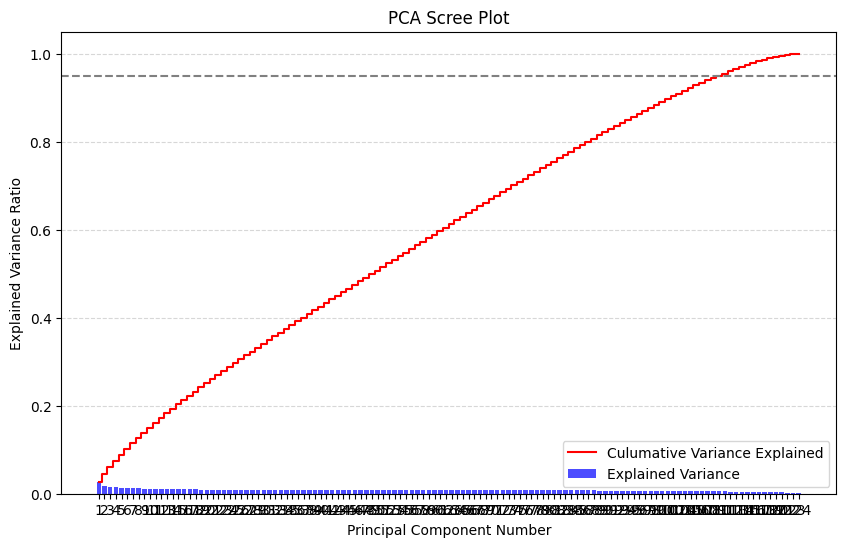

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(range(1,len(explained_variance_ratio)+1),explained_variance_ratio,label='Explained Variance',color='blue',alpha=0.7,align='center')
plt.step(range(1,len(cumulative_explained_variance_ratio)+1),cumulative_explained_variance_ratio,where='mid',label='Culumative Variance Explained',color='red')
plt.title('PCA Scree Plot')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Number')
plt.legend(loc='best')
plt.axhline(y=0.95,color='gray',linestyle='--',label='95% Threshold')
plt.xticks(range(1,len(cumulative_explained_variance_ratio)+1))
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

Convert to tensors. Batch, shuffle and load training and validation sets.

In [ ]:
x_train_transformed = pca.transform(train_dataset.x)

train_features = torch.tensor(x_train_transformed, dtype=torch.float32)
train_labels = torch.tensor(train_dataset.y, dtype=torch.float32)
train_dataset = torch.utils.data.TensorDataset(train_features, train_labels)
val_features = torch.tensor(pca.transform(val_dataset.x), dtype=torch.float32)
val_labels = torch.tensor(val_dataset.y, dtype=torch.float32)
val_dataset = torch.utils.data.TensorDataset(val_features, val_labels)

In [ ]:
BATCH_SIZE = 1024
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,pin_memory=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,pin_memory=True)

input_size = x_train_transformed.shape[1]
print(f"Input (features) size: {input_size}")

Input (features) size: 124


## Hyperparameter Tuning

Choose a learning rate by trainig a new model for various learning rates. Perform forward pass, backpropagation, and updates in generate the neural network. Choose the learning rate witht smallest RMSE.

In [ ]:
learning_rates = [0.01, 0.001, 0.0001]
results = {}

for lr in learning_rates:
    print(f"\nTesting Learning Rate: {lr}")

    # 1. Re-initialize model (Fresh start for every LR)
    # Note: Use input_size_pca if using PCA data, or dataset.x.shape[1] if using raw data
    input_dim = input_size
    temp_model = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    ).to(device)

    optimizer = optim.Adam(temp_model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # 2. Short Training Run (e.g., 5-10 epochs is enough to see the trend)
    for epoch in range(10):
        temp_model.train()
        for features, labels in train_loader: # Use your PCA loader here
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = temp_model(features)
            loss = criterion(outputs, labels.view(-1, 1))
            loss.backward()
            optimizer.step()

    # 3. Check Validation Loss
    mse, rmse, r2 = calculate_metrics(temp_model, val_loader, device)
    results[lr] = rmse
    print(f"LR {lr} -> Validation RMSE: {rmse:.4f}")

# Find best LR
best_lr = min(results, key=results.get)
print(f"\nBest Learning Rate found: {best_lr}")


Testing Learning Rate: 0.01
LR 0.01 -> Validation RMSE: 18.1133

Testing Learning Rate: 0.001
LR 0.001 -> Validation RMSE: 18.0685

Testing Learning Rate: 0.0001
LR 0.0001 -> Validation RMSE: 35.0028

Best Learning Rate found: 0.001


# NN Rev B

In [ ]:
"""
model = nn.Sequential(
    # Layer 1
    nn.Linear(input_size,128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.2),
    # Layer 2
    nn.Linear(128,64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.1),
    # Layer 3
    nn.Linear(64,32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    # Layer 4
    nn.Linear(32,16),
    nn.ReLU(),
    # Layer 5
    nn.Linear(16,1)
)

model = model.to(device) # move to GPU

loss_type = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0

print("Starting Training")

start_time = time.time()

for epoch in range(num_epochs):
  model.train()
  epoch_loss = 0.0

  for features, labels in train_loader:
    features, labels = features.to(device), labels.to(device) # move data to GPU

    optimizer.zero_grad()
    # forward pass, predicted
    predictions = model(features)
    # loss
    loss = loss_type(predictions, labels.view(-1,1))
    #backprop, gradients and update weights

    loss.backward()
    optimizer.step()
    #update loss
    epoch_loss += loss.item()

  # validation test
  model.eval()
  val_loss = 0.0
  with torch.no_grad():
    for features, labels in val_loader:
      features, labels = features.to(device), labels.to(device)
      predictions = model(features)
      val_loss += loss_type(predictions, labels.view(-1,1)).item()

  avg_train_loss = epoch_loss / len(train_loader)
  avg_val_loss = val_loss / len(val_loader)

  if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch+1}/{num_epochs} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")
  if avg_val_loss < best_val_loss:
    best_val_loss = avg_val_loss
    patience_counter = 0
  else:
    patience_counter += 1
    if patience_counter >= patience:
      print(f"Early stopping at epoch {epoch+1}")
      break

print("Training finished")
print(f"Done in {time.time() - start_time:.2f}s")
mse, rmse, r2 = calculate_metrics(model, val_loader, device)
print(f"Final Validation Results -> MSE: {mse:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")
"""

Starting Training
Epoch 5/100 | Train: 454.2660 | Val: 514.9729
Epoch 10/100 | Train: 256.5850 | Val: 363.9346
Epoch 15/100 | Train: 250.4020 | Val: 363.3973
Epoch 20/100 | Train: 245.4701 | Val: 362.2396
Epoch 25/100 | Train: 242.1016 | Val: 360.9919
Epoch 30/100 | Train: 239.8814 | Val: 362.6350
Epoch 35/100 | Train: 238.4898 | Val: 363.7151
Epoch 40/100 | Train: 235.6612 | Val: 360.6527
Early stopping at epoch 44
Training finished
Done in 80.01s
Final Validation Results -> MSE: 315.83 | RMSE: 17.77 | R2: 0.3044


## NN Rev C

Implement a more advanced neural network. We use BatchNorm, Dropout, Silu, and a funnel-shaped design. We also use AdamE, a learning-rate scheduler, graident clipping, and early stopping to reduce overfitting. Learning rate is changed if validation loss doesn't change much.

In [ ]:
# 1. THE ADVANCED ARCHITECTURE
class SpotifyAdvancedNN(nn.Module):
    def __init__(self, input_size):
        super(SpotifyAdvancedNN, self).__init__()

        # We use a "Funnel" shape: Wide input -> narrow output
        # We use SiLU (Swish) instead of ReLU for better gradient flow

        self.network = nn.Sequential(
            # --- Layer 1: Expansion ---
            nn.Linear(input_size, 256),   # Go wide first to capture interactions
            nn.BatchNorm1d(256),          # Stabilize
            nn.SiLU(),                    # Modern activation
            nn.Dropout(0.3),              # 30% dropout to fight overfitting

            # --- Layer 2: Compression ---
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.3),

            # --- Layer 3: Deep Reasoning ---
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Dropout(0.2),

            # --- Layer 4: Fine Tuning ---
            nn.Linear(64, 32),
            nn.SiLU(),

            # --- Output Layer ---
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

# 2. INITIALIZE (Assuming train_loader and device are already defined)
input_size = x_train_transformed.shape[1]
model = SpotifyAdvancedNN(input_size).to(device)

print(model)

# 3. ADVANCED OPTIMIZER & SCHEDULER
# AdamW fights overfitting better than standard Adam
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Scheduler: If validation loss doesn't improve for 5 epochs, cut LR by 10%
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

criterion = nn.MSELoss()

# 4. ROBUST TRAINING LOOP
num_epochs = 100
patience = 15 # Wait longer before early stopping
best_val_loss = float('inf')
patience_counter = 0

print("Starting Advanced Training...")

for epoch in range(num_epochs):
    # --- TRAIN ---
    model.train()
    epoch_loss = 0.0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        predictions = model(features)
        loss = criterion(predictions, labels.view(-1, 1))
        loss.backward()

        # Gradient Clipping: Prevents "exploding" gradients in deep networks
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item()

    # --- VALIDATE ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            preds = model(features)
            v_loss = criterion(preds, labels.view(-1, 1))
            val_loss += v_loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    # STEP THE SCHEDULER
    # This tells PyTorch: "Here is the current loss, adjust LR if stuck"
    scheduler.step(avg_val_loss)

    # Logging
    current_lr = optimizer.param_groups[0]['lr']
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1} | Train: {avg_train_loss:.1f} | Val: {avg_val_loss:.1f} | LR: {current_lr:.6f}")

    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save the best model state
        torch.save(model.state_dict(), 'best_spotify_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early Stopping triggered at Epoch {epoch+1}")
            break

print("Training Finished.")

SpotifyAdvancedNN(
  (network): Sequential(
    (0): Linear(in_features=124, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): SiLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
  )
)
Starting Advanced Training...
Epoch 5 | Train: 705.3 | Val: 795.3 | LR: 0.001000
Epoch 10 | Train: 636.6 | Val: 736.3 | LR: 0.001000
Epoch 15 | Train: 588.9 | Val: 695.5 | LR: 0.001000
Epoch 

Compute MSE, RMSE, and R^2.

In [ ]:
mse, rmse, r2 = calculate_metrics(model, val_loader, device)
print(f"Final Validation Results -> MSE: {mse:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")

Final Validation Results -> MSE: 353.20 | RMSE: 18.79 | R2: 0.2221


Create a scatterplot compare actual vs predicted popularity. The diagonal line represents perfect predictive capability.

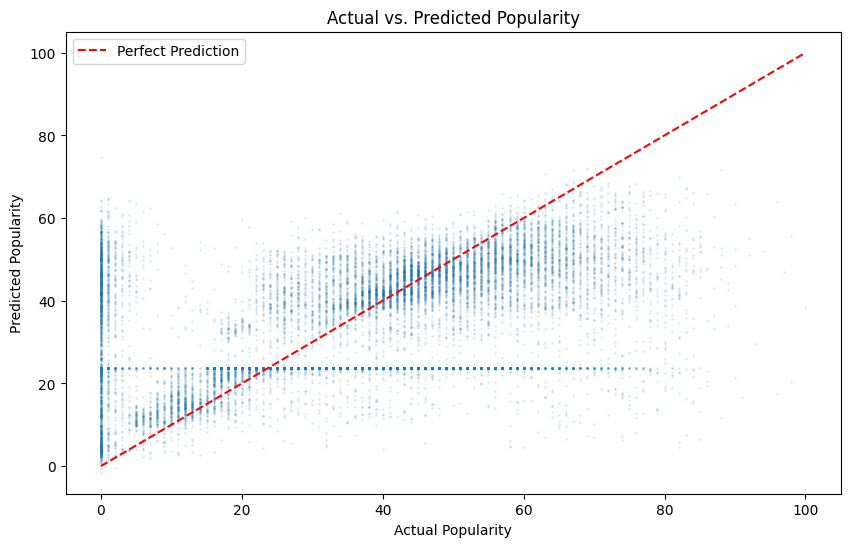

In [ ]:
def plot_actual_vs_predicted(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            preds = model(features).cpu().flatten()
            all_preds.extend(preds)
            all_labels.extend(labels)

    plt.figure(figsize=(10, 6))
    plt.scatter(all_labels, all_preds, alpha=0.1, s=1) # Alpha makes overlaps visible

    # Plot a perfect diagonal line (Ideal predictions)
    plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Perfect Prediction')

    plt.xlabel('Actual Popularity')
    plt.ylabel('Predicted Popularity')
    plt.title('Actual vs. Predicted Popularity')
    plt.legend()
    plt.show()

# Run it
plot_actual_vs_predicted(model, val_loader, device)